# Analyse TLS Handshake Results



# 1. Definitions

Run this section first to define the functions needed to analyse specific 
scenarios.

## 1.0 Globals

In [514]:
RESULTS_DIR = "./server-tls-results/"

## 1.1 Imports

In [515]:
import pandas as pd
import os
import scipy
import scipy.stats
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

# 1.2 Load a test set

In [516]:
def load_algorithm_results(
    alg_results_dir: str,
    ind_var_shortname: str,
) -> pd.DataFrame:
    """Loads the results from a specific algorithm's results dir for a given test
    set.

    Arguments:
    - alg_results_dir: the directory containing that alg's results for a test 
    set.
    - alg_name: The long name of an algorithm for graphs etc.
    - ind_var_shorname: the shortname (e.g. CSV subheading) of the test's
    dependent variable.
    - ind_var_longname: The "long name" of the dependent variable e.g. "Packet 
    Loss Rate"
    """

    # load the file
    with open(RESULTS_DIR + alg_results_dir + "/batch-parameters.csv", "r") as csv:
        batch_parameters = pd.read_csv(csv)


    batch_ind_var_values = pd.Series( 
        data=dict(zip(batch_parameters["batch_number"], batch_parameters[ind_var_shortname])),
        index=batch_parameters['batch_number']
    )

    # load all the results into a DataFrame

    results = {} # it's easier to load them into a dict then convert that
    # dict to a DataFrame at the end, DataFrame's aren't built to be modfied
    # in-place very much.

    # read all of the batch-n.data files into one dataframe.
    for batch_number in batch_ind_var_values.index.to_list():
        batch_filename = f"{RESULTS_DIR}{alg_results_dir}/batch-{batch_number}.data"
        ind_var = batch_ind_var_values[batch_number]
        with open(batch_filename, "r") as batch_file:
            batch_durations = batch_file.read().split(",")
            results[ind_var] = [float(duration) for duration in batch_durations]

    results = dict([ (k, pd.Series(v)) for k,v in results.items()]) # trick to create a dataframe
    # with different sized columns.
    # https://plainenglish.io/python/a-quick-trick-to-make-dataframes-with-uneven-array-lengths-32bf80d8a61d
 
    results_df = pd.DataFrame(results).replace(-1,None)
    return results_df


# 1.2 Statistically Analyse a test set

In [517]:
def analyse_test_set(test_set: pd.DataFrame, inverse=False):
    # get the list of independent variable values
    # inverse is used to put the test sets in reverse order, e.g. for bandwidth
    if inverse:
        batches = list(test_set)[::-1]
    else:
        batches = list(test_set)
    test_set_stats = {}
    test_set_stats = {
        "ind_var_value": [],
        "mean": [],
        "median": [],
        "CI_low": [],
        "CI_high": [],
        "trimmed_mean": [],
        "significant": []
    }
    # calculate useful statistics for each batch
    for batch_ind_var in batches:
        batch = pd.to_numeric(test_set[batch_ind_var],errors="coerce").dropna()
        test_set_stats["ind_var_value"].append(batch_ind_var)
        test_set_stats["mean"].append(batch.mean())
        test_set_stats["median"].append(batch.median())
        # basic (i.e. non-corrected) bootstrap against the batch results.
        # get low and high CI value
        ci_low, ci_high = scipy.stats.bootstrap(
            (batch.to_numpy(),),
            np.mean,
            method="basic").confidence_interval
        test_set_stats["CI_low"].append(ci_low)
        test_set_stats["CI_high"].append(ci_high)
        # use confidence intervals to test the significance of the results.
        try:
            test_set_stats["significant"].append(
                not test_set_stats["CI_low"][0] < test_set_stats["mean"][-1] < test_set_stats["CI_high"][0]
            )
        except:
            # handle the error if it's the first batch
            test_set_stats["significant"].append(False)
        # calculate trimmed mean, i.e. mean of the middle 90%
        test_set_stats["trimmed_mean"].append(scipy.stats.trim_mean(
            batch, 0.05
        ))

    # return a dataframe
    return pd.DataFrame(test_set_stats)
    


# 1.3 Plot all 6 KEMS

In [518]:
def plot_all_kems(ind_var_shortname:str, ind_var_longname: str, stat: str = "trimmed_mean", subdir="latency", inverse=False, logy=False, logx=False):
    mlkem512 = analyse_test_set(load_algorithm_results(f"/{subdir}/secLevel1/mlkem512", ind_var_shortname), inverse=inverse)
    hqc128 = analyse_test_set(load_algorithm_results(f"/{subdir}/secLevel1/hqc128", ind_var_shortname), inverse=inverse)
    mlkem768 = analyse_test_set(load_algorithm_results(f"/{subdir}/secLevel3/mlkem768", ind_var_shortname), inverse=inverse)
    hqc192 = analyse_test_set(load_algorithm_results(f"/{subdir}/secLevel3/hqc192", ind_var_shortname), inverse=inverse)
    mlkem1024 = analyse_test_set(load_algorithm_results(f"/{subdir}/secLevel5/mlkem1024", ind_var_shortname), inverse=inverse)
    hqc256 = analyse_test_set(load_algorithm_results(f"/{subdir}/secLevel5/hqc256", ind_var_shortname), inverse=inverse)

    fig, (ax_level1, ax_level3, ax_level5, ax_all) = plt.subplots(4,1)
    fig.tight_layout()
    if logy:
        ax_level1.set_yscale("log", base=10)
        ax_level3.set_yscale("log", base=10)
        ax_level5.set_yscale("log", base=10)
        ax_all.set_yscale("log", base=10)
    if logx:
        ax_level1.set_xscale("log", base=2)
        ax_level1.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: str(float(x))))
        ax_level3.set_xscale("log", base=2)
        ax_level3.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: str(float(x))))
        ax_level5.set_xscale("log", base=2)
        ax_level5.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: str(float(x))))
        ax_all.set_xscale("log", base=2)
        ax_all.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: str(float(x))))
    if inverse:
        ax_level1.xaxis.set_inverted(True)
        ax_level3.xaxis.set_inverted(True)
        ax_level5.xaxis.set_inverted(True)
        ax_all.xaxis.set_inverted(True)
    fig.set_size_inches(10,15)
    ax_level1.plot(mlkem512["ind_var_value"], mlkem512[stat], label="ML-KEM 512")
    ax_level1.plot(hqc128["ind_var_value"],hqc128[stat], label="HQC-128")
    ax_level1.legend()
    ax_level1.set_title("Security Level 1")
    ax_level1.set_xlabel(ind_var_longname)
    ax_level1.grid()
    ax_level1.set_ylabel("Handshake duration (ms)")

    ax_level3.plot(mlkem768["ind_var_value"],mlkem768[stat], label="ML-KEM 768")
    ax_level3.plot(hqc192["ind_var_value"],hqc192[stat], label="HQC-192")
    ax_level3.legend()
    ax_level3.set_title("Security Level 3")
    ax_level3.set_xlabel(ind_var_longname)
    ax_level3.grid()
    ax_level3.set_ylabel("Handshake duration (ms)")

    ax_level5.plot(mlkem1024["ind_var_value"],mlkem1024[stat], label="ML-KEM 1024")
    ax_level5.plot(hqc256["ind_var_value"],hqc256[stat], label="HQC-256")
    ax_level5.legend()
    ax_level5.set_title("Security Level 5")
    ax_level5.set_xlabel(ind_var_longname)
    ax_level5.grid()
    ax_level5.set_ylabel("Handshake duration (ms)")



    ax_all.plot(mlkem512["ind_var_value"], mlkem512[stat], label="ML-KEM 512")
    ax_all.plot(hqc128["ind_var_value"],hqc128[stat], label="HQC-128")
    ax_all.plot(mlkem768["ind_var_value"],mlkem768[stat], label="ML-KEM 768")
    ax_all.plot(hqc192["ind_var_value"],hqc192[stat], label="HQC-192")
    ax_all.plot(mlkem1024["ind_var_value"],mlkem1024[stat], label="ML-KEM 1024")
    ax_all.plot(hqc256["ind_var_value"],hqc256[stat], label="HQC-256", )
    ax_all.set_xlabel(ind_var_longname)
    ax_all.set_ylabel("Handshake duration (ms)")
    ax_all.grid()
    ax_all.legend()


    

# 2 Analyse and Plot Data

# 2.1 Latency

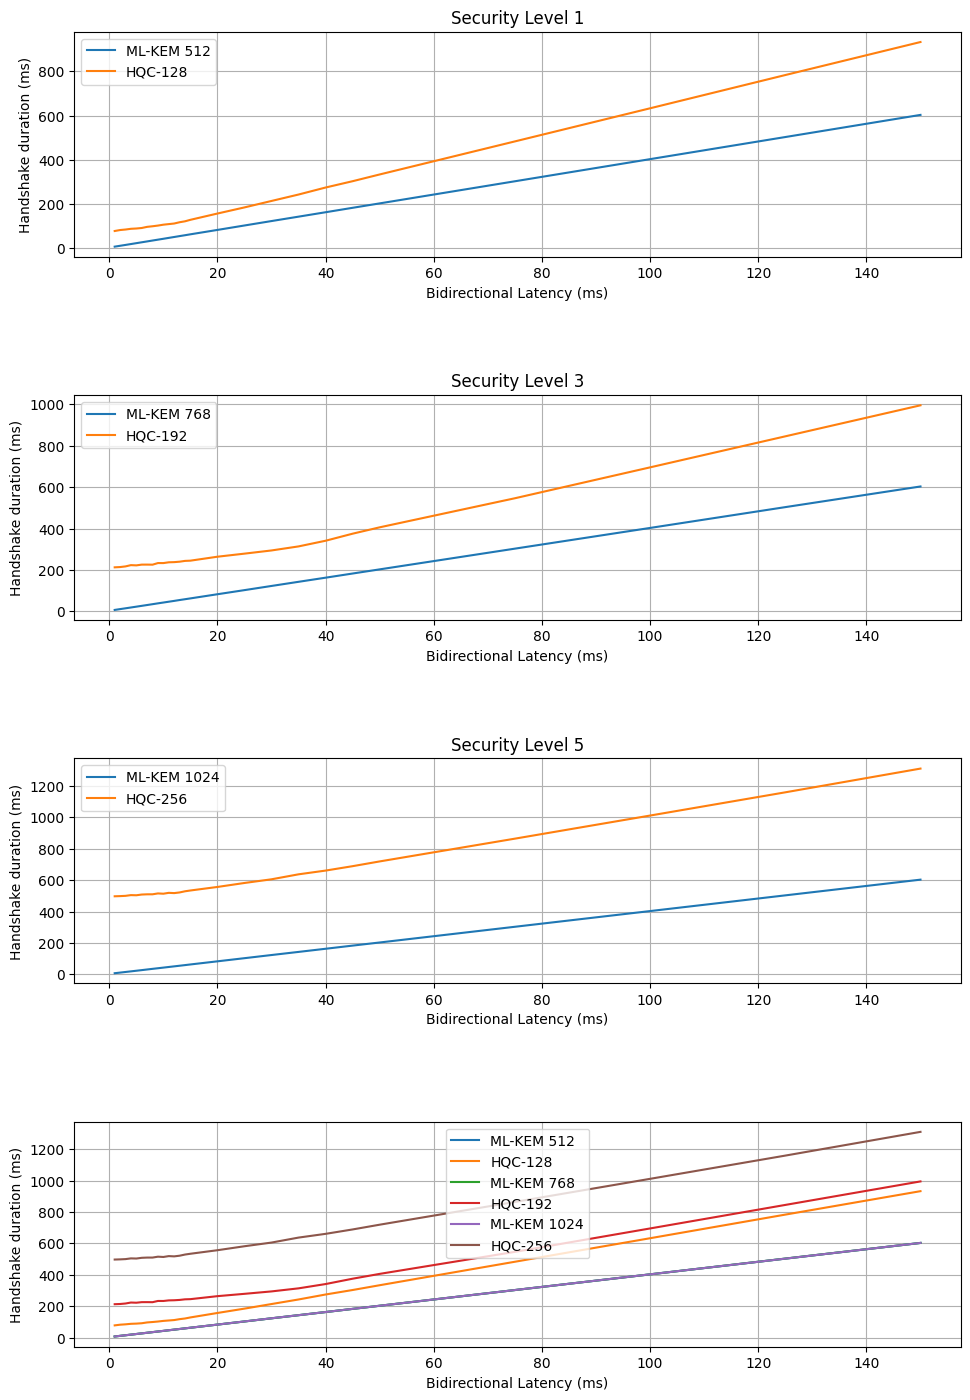

In [519]:
plot_all_kems("delay", "Bidirectional Latency (ms)", subdir="latency")

## 2.2 Packet Loss Rates

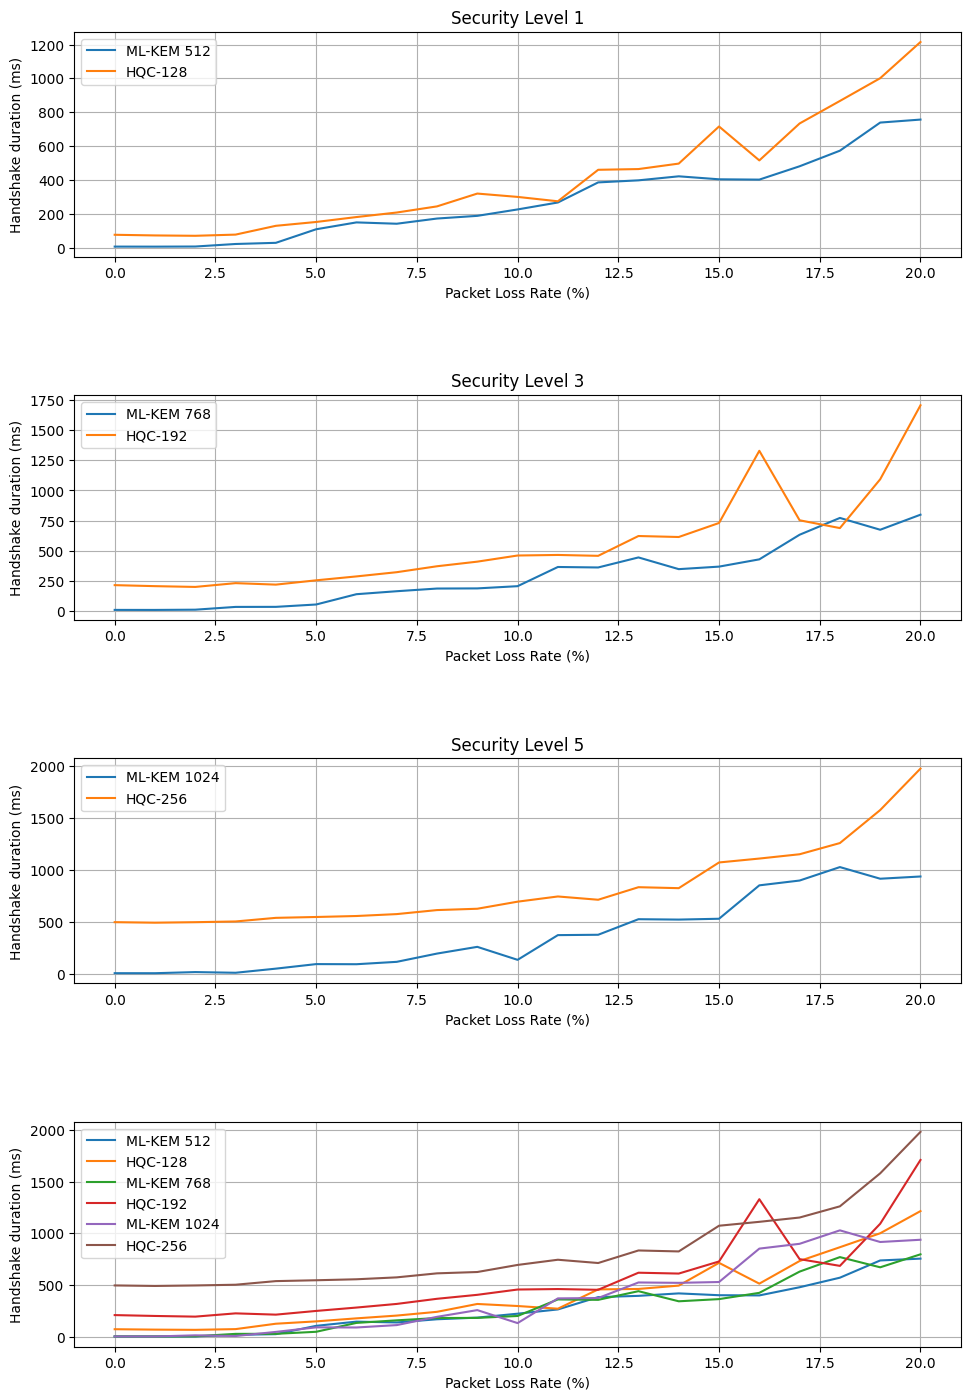

In [520]:
plot_all_kems("packet_loss", "Packet Loss Rate (%)", subdir="packet_loss", inverse=False)

## 2.3 Bandwidth (Client to Server)

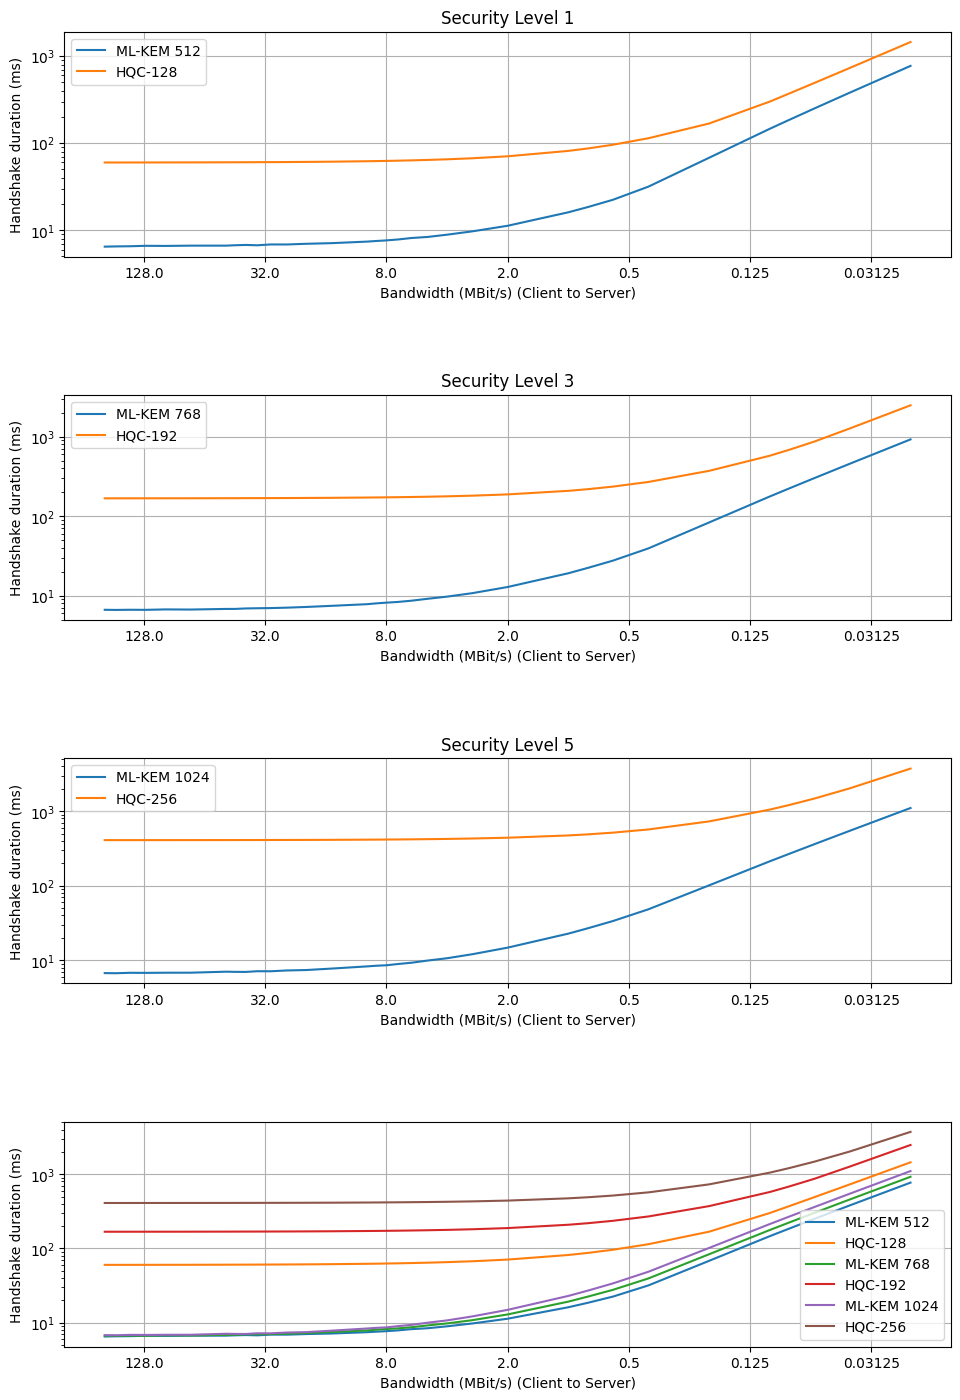

In [521]:
plot_all_kems("client_rate", "Bandwidth (MBit/s) (Client to Server)", subdir="bandwidth-client-to-server", inverse=True, logy=True, logx=True)

## 2.4 Bandwidth (Server to Client)

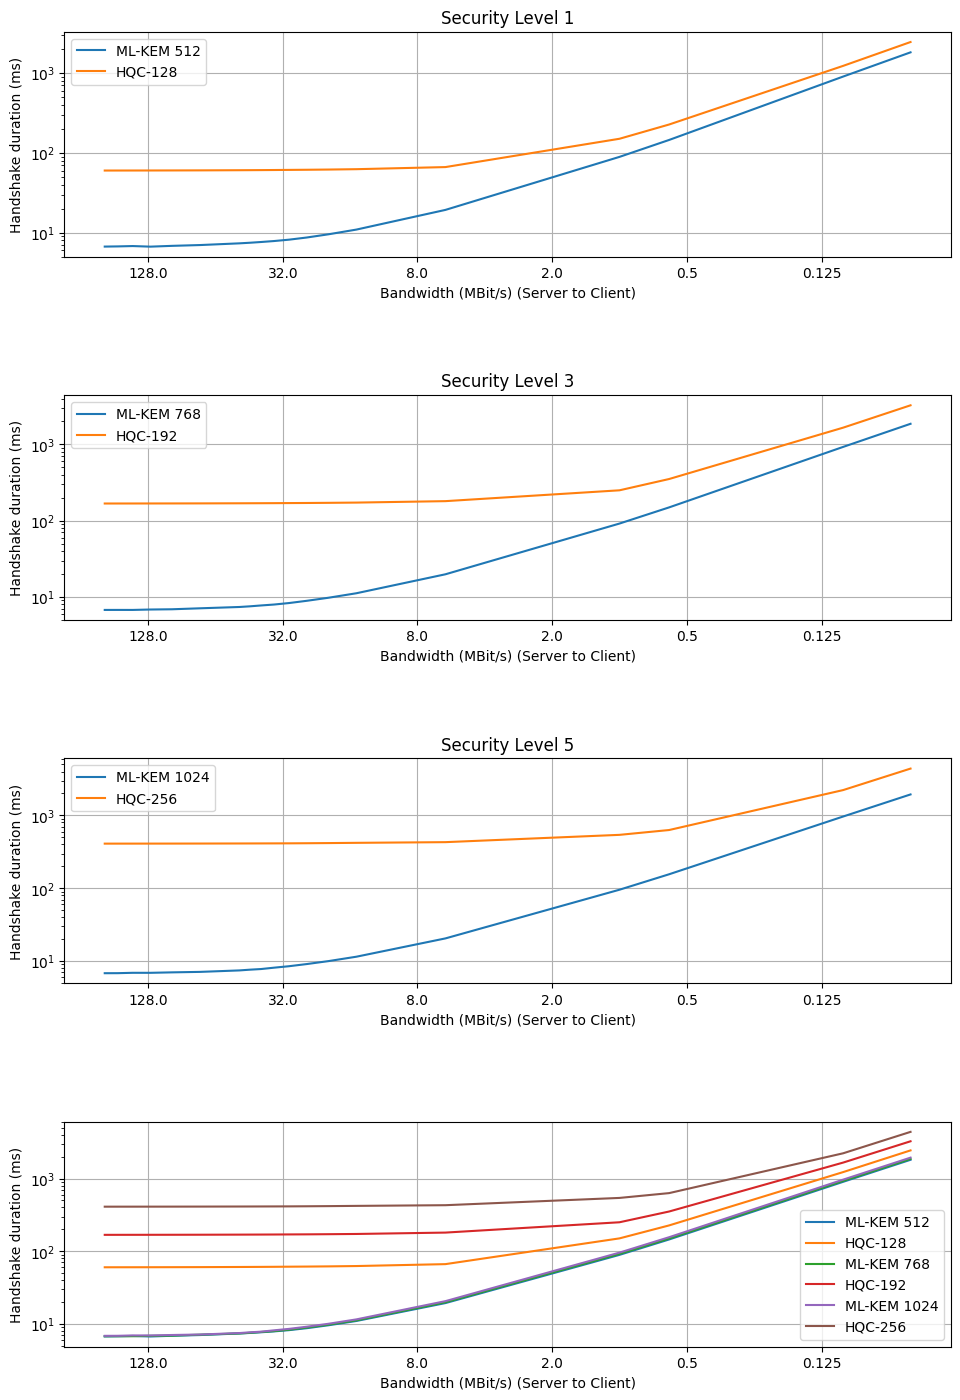

In [524]:
plot_all_kems("server_rate", "Bandwidth (MBit/s) (Server to Client)", subdir="bandwidth-server-to-client", inverse=True, logy=True, logx=True)

## 2.5 Bandwidth (Bidirectional)

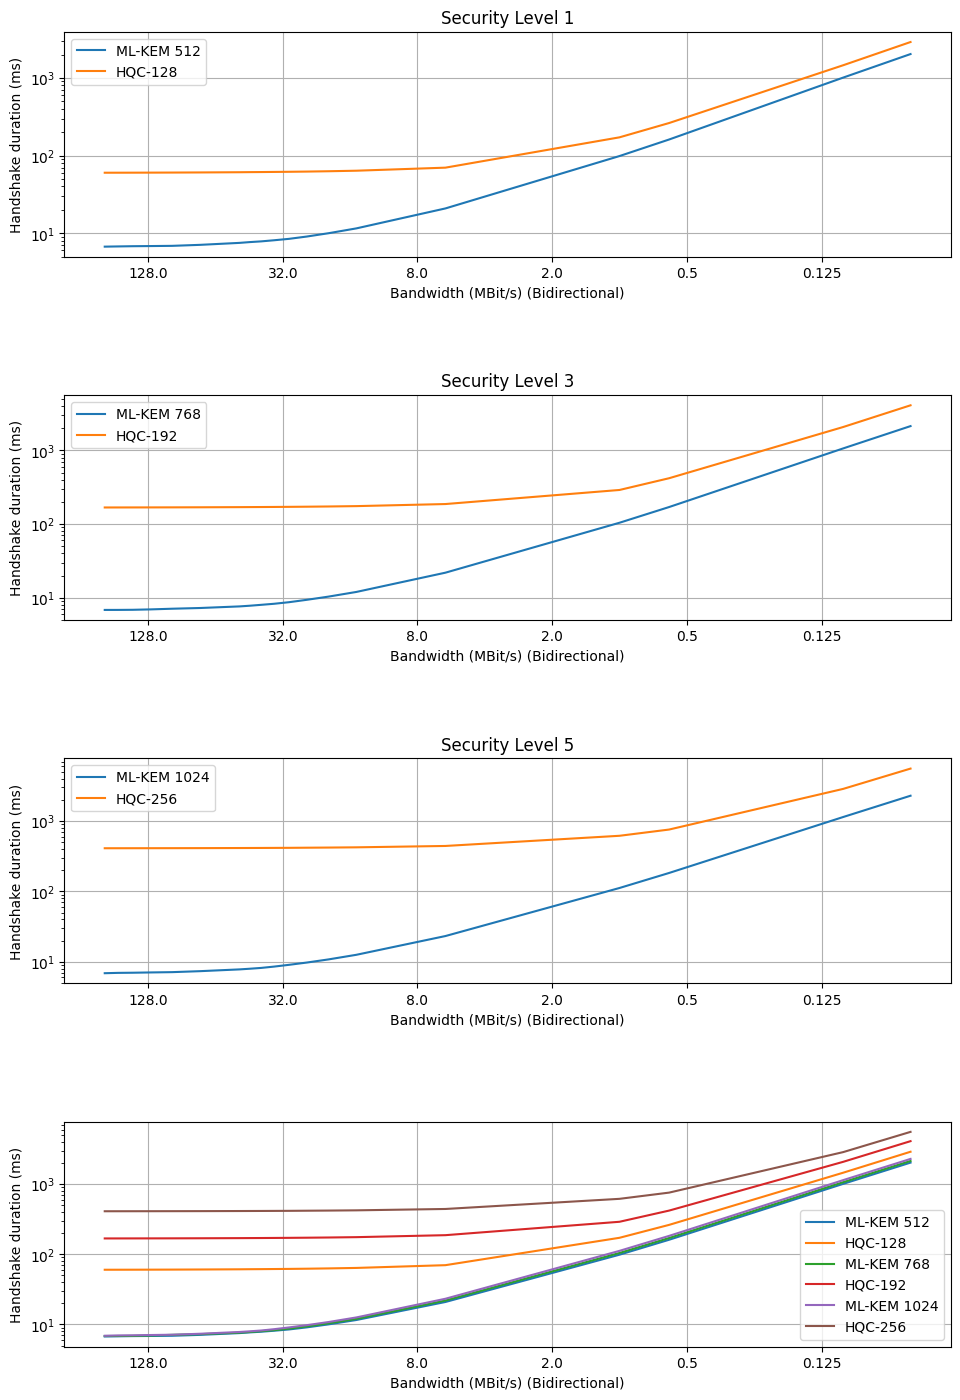

In [525]:
plot_all_kems("client_rate", "Bandwidth (MBit/s) (Bidirectional)", subdir="bandwidth-bidirectional", inverse=True, logy=True, logx=True)

# X Testing

In [523]:
hqc_test = load_algorithm_results("/bandwidth-bidirectional/secLevel5/hqc256/", "client_rate")
hqc_test_stats = analyse_test_set(hqc_test)
hqc_test_stats
#test_sr=hqc_test[75.0]
#hqc_test_stats.plot(x="ind_var_value", y="trimmed_mean")

,ind_var_value,mean,median,CI_low,CI_high,trimmed_mean,significant
0,0.05,5559.189031,5560.157058,5558.176096,5561.192907,5560.173912,False
1,0.10,2861.374579,2861.456421,2861.268209,2861.564363,2861.462879,True
2,0.60,756.739264,756.682627,756.695975,756.779291,756.719410,True
3,1.00,617.027677,616.958795,616.905810,617.105419,616.968434,True
4,6.00,442.271708,442.245182,442.222511,442.310457,442.251445,True
5,15.00,422.951011,422.952427,422.915518,422.983952,422.942282,True
6,20.00,419.684457,419.675882,419.647051,419.720668,419.680460,True
7,25.00,417.825778,417.707841,417.653780,417.951506,417.708584,True
8,30.00,416.043226,416.040679,416.013838,416.072306,416.038467,True
9,35.00,415.193551,415.098111,415.070095,415.269715,415.138959,True
